In [1]:
print("hello")

hello


In [2]:
%%time
import tensorflow as tf
print("TF Version:", tf.__version__)
print("Devices:", tf.config.list_physical_devices())

TF Version: 2.20.0
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
CPU times: total: 8.81 s
Wall time: 52.8 s


In [3]:
import os
from pathlib import Path
from PIL import Image
import psutil
from tqdm import tqdm

import pandas as pd
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import numpy as np
import random
import cv2

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import pandas as pd
import numpy as np

# DATA HANDLING

* **Manage satellite image datasets using Keras and Python libraries**

* **Compare memory-based and generator-based data loading strategies in terms of performance, memory efficiency, and implementation complexity**

* **Build a simple, memory-efficient image pipeline by loading and visualizing geospatial image data sequentially**

* **Assess the trade-offs between loading entire image datasets into memory versus accessing image paths on demand**


In [4]:
PROJECT_ROOT = ".."
RAW_DIR = os.path.join(PROJECT_ROOT, "data", "raw", "images_dataSAT")
dir_agri = os.path.join(RAW_DIR, "class_1_agri")
dir_non_agri = os.path.join(RAW_DIR, "class_0_non_agri")
(dir_agri, dir_non_agri)

('..\\data\\raw\\images_dataSAT\\class_1_agri',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri')

class_0_non_agri is the non-agricultural land class, as defined earlier, and it represents images with non-cultivable land.
class_1_agri, on the other hand, is the agricultural land class, and it represents the images with cultivable land.

**os.scandir** to build an iterator

In [5]:
non_agri = os.scandir(dir_non_agri)

for i in range(3):
    print(next(non_agri))

<DirEntry 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6074.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6246.jpg'>


In [6]:
file_name = next(non_agri)
image_name = str(file_name).split("'")[1]
image_name

'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6247.jpg'

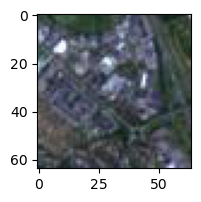

In [7]:
image_data = plt.imread(os.path.join(dir_non_agri, image_name))
image_data.shape
plt.figure(figsize=(4, 2))
plt.imshow(image_data)

<b>Strategy 1 — Memory-Based Loading</b><br>
Load every single image from disk into RAM at once, store them all as a big NumPy array.

In [8]:
def get_ram_usage_mb():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 ** 2)  

In [9]:
%%time

before_ram = get_ram_usage_mb()

non_agri_images = []
non_agri = os.scandir(dir_non_agri)

for file_name in non_agri:
    if os.path.isfile(file_name):
        image_name = str(file_name).split("'")[1]
        image_data = plt.imread(os.path.join(dir_non_agri,image_name))
        non_agri_images.append(image_data)

non_agri_images = np.array(non_agri_images)        

after_ram = get_ram_usage_mb()
print(f"RAM used: {after_ram - before_ram:.2f} MB")

RAM used: 37.67 MB
CPU times: total: 3.45 s
Wall time: 3.8 s


In [10]:
agri_images = []

for entry in os.scandir(dir_agri):
    if entry.is_file():
        image_data = plt.imread(entry.path)
        agri_images.append(image_data)

agri_images = np.array(agri_images)

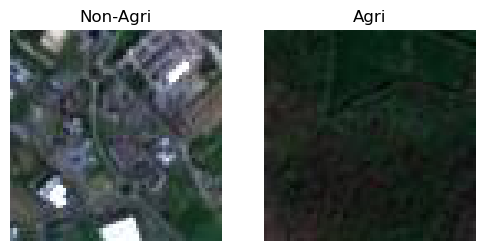

In [11]:
plt.figure(figsize=(6, 3))

# Left image (non-agri)
plt.subplot(1, 2, 1)
plt.imshow(non_agri_images[1])
plt.title("Non-Agri")
plt.axis('off')

# Right image (agri)
plt.subplot(1, 2, 2)
plt.imshow(agri_images[1])
plt.title("Agri")
plt.axis('off')

plt.show()

<b>Strategy 2 — Generator/Path-Based </b><br>
Store only the file paths (strings) in memory. Open each image only when you actually need it — one at a time or one batch at a time.

In [12]:
%%time

before_ram = get_ram_usage_mb()

non_agri_images = os.listdir(dir_non_agri) #listdir gives names only
non_agri_images.sort()
non_agri_images_paths = [os.path.join(dir_non_agri,image) for image in non_agri_images]

after_ram = get_ram_usage_mb()

print(f"RAM used: {after_ram - before_ram:.2f} MB")

RAM used: -34.20 MB
CPU times: total: 46.9 ms
Wall time: 34 ms


Looking at the results of psutil and %%time , Path based generator will be better in terms of memory required

In [13]:
non_agri_images[:5]

['tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6074.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6246.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6247.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6248.jpg']

In [14]:
non_agri_images_paths[:5]

['..\\data\\raw\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6074.jpg',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6246.jpg',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6247.jpg',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6248.jpg']

In [15]:
len(non_agri_images_paths)

3000

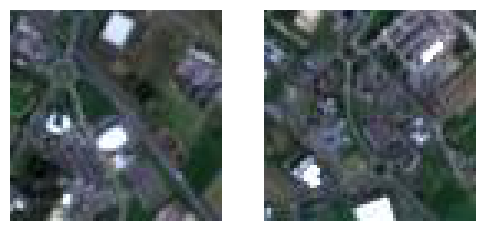

In [16]:
plt.figure(figsize=(6, 3))

for i in range(2):
    img = Image.open(non_agri_images_paths[i])

    plt.subplot(1, 2, i + 1)
    plt.imshow(img)
    plt.axis('off')

plt.show()

In [17]:
agri_images = os.listdir(dir_agri)
agri_images.sort()
agri_images_paths = [os.path.join(dir_agri,image) for image in agri_images]
len(agri_images_paths)

3000

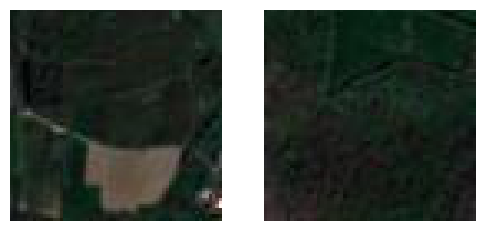

In [18]:
plt.figure(figsize=(6,3))

for i in range(2):
    img = Image.open(agri_images_paths[i])
    plt.subplot(1,2,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [19]:
(PROJECT_ROOT, RAW_DIR, dir_agri, dir_non_agri)

('..',
 '..\\data\\raw\\images_dataSAT',
 '..\\data\\raw\\images_dataSAT\\class_1_agri',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri')

### Pre - Proccessing
Only deterministic preprocessing is done before split; no statistical normalization is applied
- Resize, format conversion (okay)
- Standardization, PCA, Tokenization leaks data 

In [20]:
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")

processed_agri = os.path.join(PROCESSED_DIR, "class_1_agri")
processed_non_agri = os.path.join(PROCESSED_DIR, "class_0_non_agri")

img_size = (64, 64)

for path in tqdm(agri_images_paths, desc="Processing Agri"): ## tqdm just for process bar
    try:
        img = Image.open(path).convert("RGB")
        img = img.resize(img_size)
        
        save_path = os.path.join(processed_agri, os.path.basename(path))
        img.save(save_path)
    except Exception as e:
        print("Skipped:", path)
        print("Error:", e)

for path in tqdm(non_agri_images_paths, desc="Processing Non-Agri"):
    try:
        img = Image.open(path).convert("RGB")
        img = img.resize(img_size)
        
        save_path = os.path.join(processed_non_agri, os.path.basename(path))
        img.save(save_path)
    except Exception as e:
        print("Skipped:", path)
        print("Error:", e)

print("Preprocessing Done")

Processing Non-Agri: 100%|████████████████████████████████████████████████████████| 3000/3000 [00:05<00:00, 510.50it/s]

Preprocessing Done


### Splits

In [21]:
(processed_agri,os.listdir(processed_agri)[0])

('..\\data\\processed\\class_1_agri',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5878.jpg')

In [22]:
filepaths = (
    [os.path.join(processed_agri, file_name) for file_name in os.listdir(processed_agri)] +
    [os.path.join(processed_non_agri, file_name) for file_name in os.listdir(processed_non_agri)]
)

In [23]:
labels = (
    [1]*len(os.listdir(processed_agri)) +
    [0]*len(os.listdir(processed_non_agri))
)

df = pd.DataFrame({
    "filepath": filepaths,
    "label": labels
})

In [24]:
train, temp = train_test_split(df, test_size=0.3, stratify=df["label"], random_state=42)
val, test = train_test_split(temp, test_size=0.5, stratify=temp["label"], random_state=42)

In [25]:
os.makedirs("../data/splits", exist_ok=True)

train.to_csv("../data/splits/train.csv", index=False)
val.to_csv("../data/splits/val.csv", index=False)
test.to_csv("../data/splits/test.csv", index=False)

print("Splits Saved")

Splits Saved


### Data Loading and Augmentation Using Keras

* **Build and test a custom data generator in Keras for efficient, on-the-fly loading, and preprocessing of image datasets.**
* **Use Keras’s `image_dataset_from_directory` utility to load and preprocess datasets with optimized performance using the `tf.data` API.**
* **Apply image augmentation and performance optimizations such as `.map()`, `.cache()`, and `.prefetch()` to build high-throughput data pipelines.**
* **Compare custom and built-in Keras data loaders in terms of code complexity, flexibility, and runtime efficiency.**


In [26]:
def augment_image(img):
    # Horizontal flip
    if random.random() > 0.5:
        img = cv2.flip(img, 1)

    # Small rotation
    if random.random() > 0.5:
        angle = random.uniform(-15, 15)
        h, w = img.shape[:2]
        M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
        img = cv2.warpAffine(img, M, (w, h))

    return img

In [27]:
def custom_data_generator(image_paths, labels, batch_size, augment=False):
    num_samples = len(image_paths)

    while True:
        # shuffle data at the beginning of each epoch
        indices = np.arange(num_samples)
        np.random.shuffle(indices)
        # images and labels stay aligned after shuffle
        shuffled_paths = np.array(image_paths)[indices]
        shuffled_labels = np.array(labels)[indices]

        # Generate batch data
        for offset in range(0, num_samples, batch_size):
            batch_paths = shuffled_paths[offset:offset+batch_size]
            batch_labels = shuffled_labels[offset:offset+batch_size]
            
            # Load and preprocess images from the batch
            batch_images = []
            for path in batch_paths:
                img = tf.keras.utils.load_img(path)
                img_array = tf.keras.utils.img_to_array(img)
                batch_images.append(img_array)

                if augment:
                    img = augment_image(img)
            
            # Normalize and yield the batch data
            yield np.array(batch_images) / 255.0, np.array(batch_labels)

In [28]:
# train_gen = custom_data_generator(train_paths, train_labels, batch_size=32, augment=True)
# val_gen   = custom_data_generator(val_paths, val_labels, batch_size=32, augment=False)

All image paths (on disk)
        ->
Shuffle
        ->
Pick 1 batch (e.g., 32)
        ->
Load only those images
        ->
Normalize
        ->
Give to model (yield)
        ->
Repeat forever

In [29]:
temp = list(zip(filepaths, labels))
np.random.shuffle(temp)
filepaths, labels = zip(*temp)

for path, label in zip(filepaths[:3], labels[:3]):
    print(path, label)

..\data\processed\class_0_non_agri\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_8272.jpg 0
..\data\processed\class_0_non_agri\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_2455.jpg 0
..\data\processed\class_0_non_agri\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_20253.jpg 0


In [30]:
batch_size = 8
data_generator = custom_data_generator(
    image_paths=filepaths,
    labels=labels,
    batch_size=batch_size
)

In [31]:
print(len(filepaths), len(labels))

6000 6000


In [32]:
images, batch_labels = next(data_generator)
# Print batch data statistics
print(f"Images batch shape: {images.shape}")
print(f"Labels batch shape: {batch_labels.shape}")

Images batch shape: (8, 64, 64, 3)
Labels batch shape: (8,)


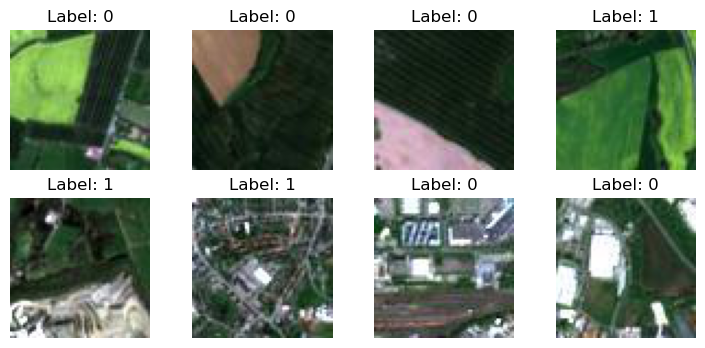

In [33]:
# Display the images in the batch
plt.figure(figsize=(9, 4))
for i in range(batch_size):
    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    plt.title(f"Label: {int(labels[i])}")
    plt.axis("off")

## Keras' built-in utility

In [34]:
batch_size = 8

In [35]:
# Create a training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    PROCESSED_DIR,
    labels='inferred',          # Labels are generated from directory structure
    label_mode='int',           # Labels are encoded as integers (0, 1, ...)
    validation_split=0.2,       # 20% of images for validation
    subset='training',          
    seed=1337,                  # Shuffle seed
    batch_size=batch_size
)

Found 6000 files belonging to 2 classes.
Using 4800 files for training.


In [36]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    PROCESSED_DIR,
    labels='inferred',
    label_mode='int',
    validation_split=0.2,
    subset='validation',
    seed=1337,
    batch_size=batch_size
)

Found 6000 files belonging to 2 classes.
Using 1200 files for validation.


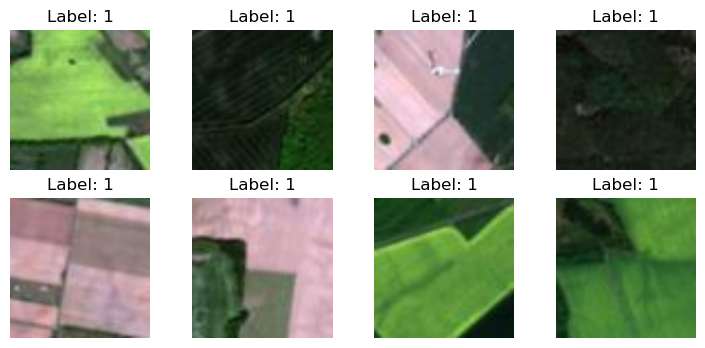

In [37]:
plt.figure(figsize=(9, 4))
for images, labels in train_ds.take(1):  # Take one batch
    for i in range(batch_size):
        ax = plt.subplot(2, 4, i + 1)
        # Images are loaded as float32, so we convert to uint8 for display
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"Label: {int(labels[i])}")
        plt.axis("off")

## Data Augmentation

In [38]:
# Normalization (ALL data)
normalization = tf.keras.layers.Rescaling(1.0 / 255)

# Augmentation (TRAIN ONLY)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1),
])

# # Train
# train_ds = train_ds.map(lambda x, y: (normalization(x), y))
# train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# # Validation
# val_ds = val_ds.map(lambda x, y: (normalization(x), y))

In [39]:
AUTOTUNE = tf.data.AUTOTUNE

# Train: normalize + augment together
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(normalization(x), training=True), y),
    num_parallel_calls=AUTOTUNE
)

# Validation: only normalize
val_ds = val_ds.map(
    lambda x, y: (normalization(x), y),
    num_parallel_calls=AUTOTUNE
)

# Performance
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## PyTorch version
1.  **Custom `Dataset` Class:** You'll build our own dataset class from scratch by inheriting from `torch.utils.data.Dataset`. This gives you full control and a deep understanding of the data pipeline.
2.  **In-built `ImageFolder` Utility:** You'll use the convenient `torchvision.datasets.ImageFolder` class, which automatically handles data from a standard directory structure.
3.  **The `DataLoader`:** You'll wrap both of our datasets in a `DataLoader`, PyTorch's engine for efficient batching, shuffling, and parallelized data loading.

1. Read CSV (train/val/test)

2. Custom Dataset class
   - load image from path
   - apply transforms

3. Define transforms
   - train → normalize + augmentation
   - val/test → normalize only

4. DataLoader
   - batching
   - shuffling (train only)

In [40]:
train_df = pd.read_csv("../data/splits/train.csv")
val_df   = pd.read_csv("../data/splits/val.csv")
test_df  = pd.read_csv("../data/splits/test.csv")

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 4200
Val: 900
Test: 900


In [41]:
train_transforms = transforms.Compose([
    transforms.ToPILImage(),

    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),

    transforms.ToTensor(),  # converts to [0,1]
])

In [42]:
val_test_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
])

In [43]:
class LandDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['filepath']
        label = self.df.iloc[idx]['label']

        # Load image
        img = cv2.imread(img_path)
        img = cv2.resize(img, (64, 64))

        # Convert BGR → RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.long)

In [44]:
train_dataset = LandDataset(train_df, transform=train_transforms)
val_dataset   = LandDataset(val_df, transform=val_test_transforms)
test_dataset  = LandDataset(test_df, transform=val_test_transforms)

In [45]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [46]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)  # [B, C, H, W]
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([32, 3, 64, 64])
Label batch shape: torch.Size([32])


## ✅ IMPORTANT ALIGNMENT (WITH YOUR KERAS PIPELINE)

<center>Now the pipelines match :</center>
<br>

| Step      | Keras     | PyTorch      |
| --------- | --------- | ------------ |
| Source    | CSV       | CSV          |
| Load      | Generator | Dataset      |
| Normalize | `/255`    | `ToTensor()` |
| Augment   | TF Layers | `transforms` |
| Batch     | `tf.data` | `DataLoader` |
